# ProteoBench intermediate format tutorial

This notebook shows how to turn a ProteoBench intermediate file into publication-style figures.

The examples below use the bundled intermediate CSV in `data/` and focus on a few patterns that show up often in ProteoBench analyses:

- loading the intermediate table into pandas
- creating a few derived columns that are convenient for plotting
- making scatter plots, box plots, and simple quality-control views with seaborn

The goal is not to be exhaustive. It is to give you a clean starting point for your own plots.

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)

palette = {
    "YEAST": "#E45756",
    "HUMAN": "#4C78A8",
    "ECOLI": "#54A24B",
}
species_order = ["YEAST", "HUMAN", "ECOLI"]

## 1. Load the intermediate file

ProteoBench intermediate files are already wide tables: each row usually represents a precursor or peptide, while columns capture intensities, ratios, observed channels, and benchmark-specific summary values.

The exact column set depends on the search engine and the benchmark setup, so the first step is always to inspect the frame and decide which columns you want to plot.

In [7]:
data_file = Path("data") / "example_intermediate_MQ_20250605_12126_result_performance.csv"
intermediate = pd.read_csv(data_file)

# A few derived columns make plotting much easier.
intermediate["log_intensity_mean"] = intermediate[["log_Intensity_mean_A", "log_Intensity_mean_B"]].mean(axis=1)
intermediate["delta_from_expected"] = intermediate["log2_A_vs_B"] - intermediate["log2_expectedRatio"]

print(f"Rows: {len(intermediate):,}")
print(f"Columns: {len(intermediate.columns):,}")
intermediate[["precursor ion", "species", "log2_A_vs_B", "log_intensity_mean", "nr_observed"]].head()

Rows: 50,845
Columns: 32


,precursor ion,species,log2_A_vs_B,log_intensity_mean,nr_observed
0,AAAAAAALQAK/2,HUMAN,0.207322,27.131828,6
1,AAAAAWEEPSSGNGTAR/2,HUMAN,0.239024,25.330867,6
2,AAAAPGASPSPGGDAAWSEAGPGPR/3,HUMAN,0.466781,23.150642,2
3,AAAAPGASPSPGGDAAWSEAGPGPRPLAR/3,HUMAN,0.490113,24.104447,6
4,AAAASAAEAGIATTGTEDSDDALLK/2,HUMAN,-0.030512,23.937211,6


## 2. Plot fold change versus intensity

This is the simplest and most common view: a scatter plot that compares the observed log2 fold change to the average log intensity.

The horizontal spread shows whether the benchmark recovered the expected ratios, while the vertical axis helps you spot intensity-dependent effects.

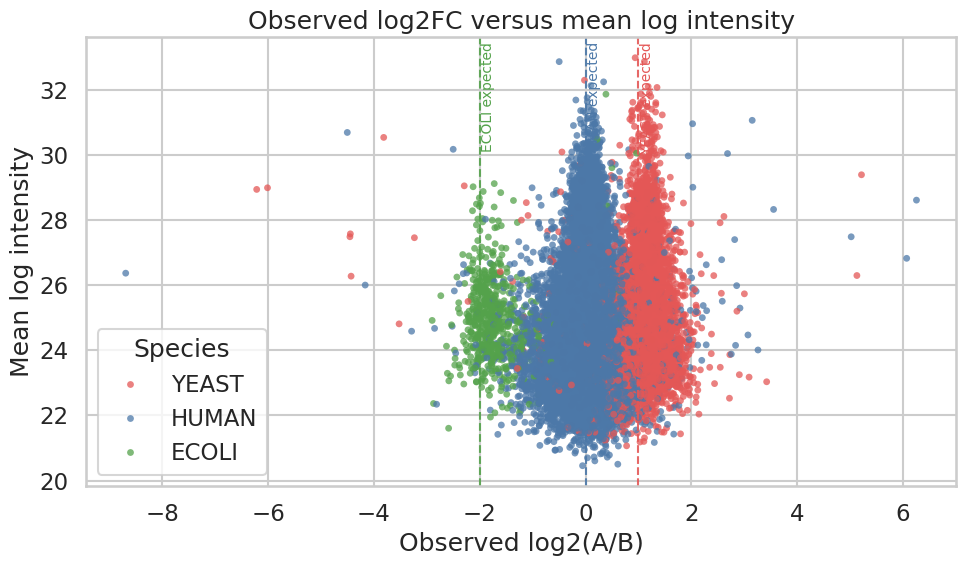

In [8]:
fig, ax = plt.subplots()

sns.scatterplot(
    data=intermediate,
    x="log2_A_vs_B",
    y="log_intensity_mean",
    hue="species",
    hue_order=species_order,
    palette=palette,
    s=24,
    alpha=0.75,
    edgecolor="none",
    ax=ax,
)

for x_value, label, color in [(0, "HUMAN expected", "#4C78A8"), (1, "YEAST expected", "#E45756"), (-2, "ECOLI expected", "#54A24B")]:
    ax.axvline(x_value, color=color, linestyle="--", linewidth=1.5, alpha=0.9)
    ax.text(x_value + 0.03, ax.get_ylim()[1] - 0.15, label, color=color, rotation=90, va="top", fontsize=10)

ax.set(
    title="Observed log2FC versus mean log intensity",
    xlabel="Observed log2(A/B)",
    ylabel="Mean log intensity",
)
ax.legend(title="Species", frameon=True)
plt.tight_layout()

## 3. Plot deviations from the expected ratio

The intermediate format already stores the expected ratio, which makes it easy to compute a residual.

A residual plot is useful when you want to see whether the benchmark error changes with intensity or differs by organism.

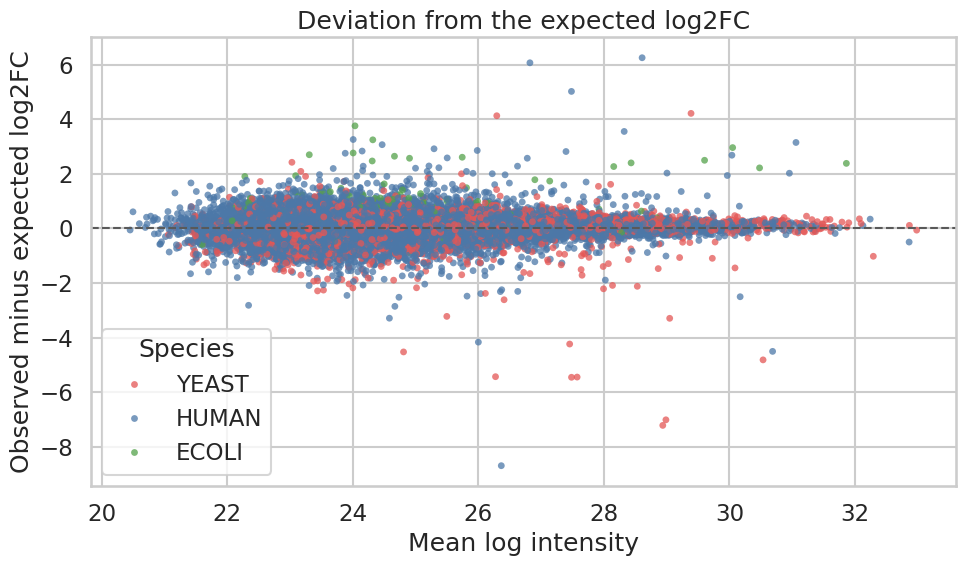

In [9]:
fig, ax = plt.subplots()

sns.scatterplot(
    data=intermediate,
    x="log_intensity_mean",
    y="delta_from_expected",
    hue="species",
    hue_order=species_order,
    palette=palette,
    s=24,
    alpha=0.75,
    edgecolor="none",
    ax=ax,
)

ax.axhline(0, color="0.35", linestyle="--", linewidth=1.5)
ax.set(
    title="Deviation from the expected log2FC",
    xlabel="Mean log intensity",
    ylabel="Observed minus expected log2FC",
)
ax.legend(title="Species", frameon=True)
plt.tight_layout()

## 5. Plot precursor CVs across conditions

The intermediate file already contains precursor-level coefficients of variation as `CV_A` and `CV_B`.

To compare the two conditions directly, reshape those columns into a long table and use a violin plot. This makes it easy to see whether one condition is systematically broader or noisier than the other.

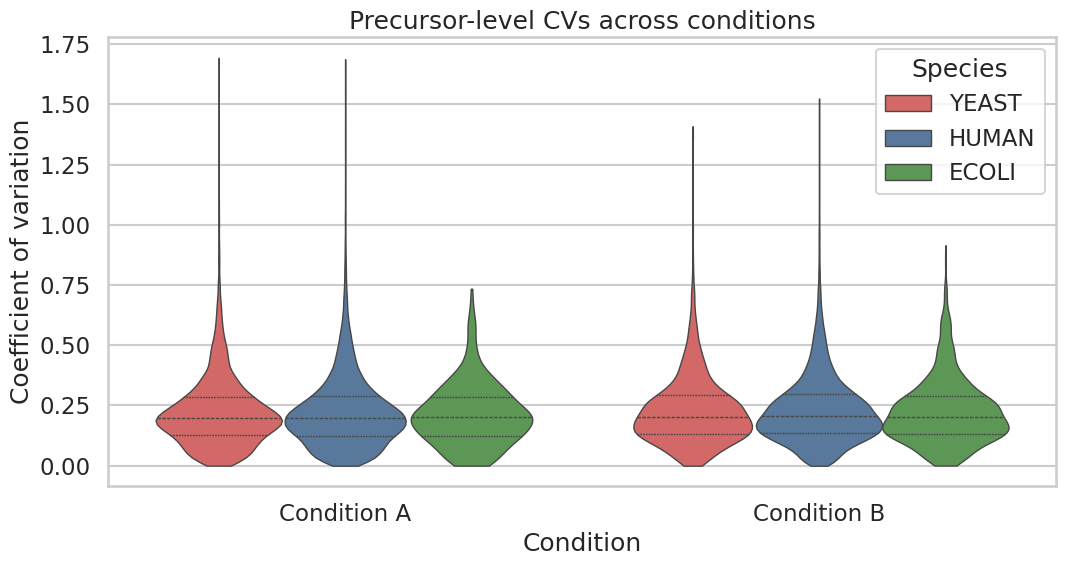

In [12]:
cv_long = intermediate.melt(
    id_vars=["species"],
    value_vars=["CV_A", "CV_B"],
    var_name="condition",
    value_name="precursor_cv",
).dropna(subset=["precursor_cv"])

cv_long["condition"] = cv_long["condition"].map({"CV_A": "Condition A", "CV_B": "Condition B"})

fig, ax = plt.subplots(figsize=(11, 6))

sns.violinplot(
    data=cv_long,
    x="condition",
    y="precursor_cv",
    hue="species",
    order=["Condition A", "Condition B"],
    hue_order=species_order,
    palette=palette,
    cut=0,
    inner="quartile",
    linewidth=1,
    ax=ax,
)

ax.set(
    title="Precursor-level CVs across conditions",
    xlabel="Condition",
    ylabel="Coefficient of variation",
)
ax.legend(title="Species", frameon=True)
plt.tight_layout()